<a href="https://colab.research.google.com/github/nuralfiyanti/ML_Ganjil2026/blob/main/JS04_SOAL_KUIS1_ML_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [ ]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [ ]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Data Size
df.shape

(48842, 15)

In [ ]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [ ]:
# Jawab Soal 1

# Pada dataset hasil fetch_ucirepo(id=2), sebagian data yang hilang sudah
# otomatis diberi label NaN, namun sebagian lainnya masih berupa string '?'.
# Samakan dulu representasinya menjadi NaN agar seluruh missing value
# terdeteksi secara konsisten oleh isnull().
df = df.replace('?', np.nan)

# 1. Inspeksi profil data secara umum
df.info()

print("\n=== Statistik Deskriptif ===")
display(df.describe(include='all').transpose())

# 2. Cek jumlah missing value pada setiap kolom
missing_value = df.isnull().sum()
missing_value = missing_value[missing_value > 0].sort_values(ascending=False)

print("\n=== Variabel dengan Missing Value ===")
print(missing_value)

total_baris_missing = df.isnull().any(axis=1).sum()
print(f"\nJumlah baris yang mengandung minimal 1 missing value: {total_baris_missing} dari {len(df)} baris")

# Jawaban:
# Berdasarkan hasil inspeksi di atas terdapat 3 variabel kategorikal yang memiliki missing value, yaitu:
#  a. workclass       : 2.799 data hilang
#  b. occupation       : 2.809 data hilang
#  c. native-country   : 857 data hilang
# Total terdapat 3.620 baris (dari 48.842 baris) yang memiliki setidaknya satu
# missing value (+/- 7,4%). Angka ini sesuai dengan statistik resmi dataset
# Adult/Census Income di UCI Repository. Jumlah pastinya dapat dilihat pada output cell di atas saat notebook
# dijalankan (workclass dan occupation memiliki jumlah missing value yang
# besar dibanding native-country).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Statistik Deskriptif ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Variabel dengan Missing Value ===
occupation        2809
workclass         2799
native-country     857
dtype: int64

Jumlah baris yang mengandung minimal 1 missing value: 3620 dari 48842 baris


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [ ]:
# Jawab Soal 2

# 1. Lakukan imputasi pada fitur kategorikal yang memiliki missing value
# Caranya: isi dengan modus (nilai yang paling sering muncul) pada masing-masing kolom
kolom_missing = ['workclass', 'occupation', 'native-country']

for kolom in kolom_missing:
    modus = df[kolom].mode()[0]
    df[kolom] = df[kolom].fillna(modus)
    print(f"Kolom '{kolom}' diisi dengan modus: '{modus}'")

# 2. Cek kembali apakah masih terdapat missing value
print("\n=== Cek Ulang Missing Value ===")
print(df.isnull().sum())

Kolom 'workclass' diisi dengan modus: 'Private'
Kolom 'occupation' diisi dengan modus: 'Prof-specialty'
Kolom 'native-country' diisi dengan modus: 'United-States'

=== Cek Ulang Missing Value ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [ ]:
# Jawab Soal 3

# 1. Inspeksi seluruh fitur kualitatif (kategorikal)
kolom_kategorikal = df.select_dtypes(include='object').columns.tolist()

for kolom in kolom_kategorikal:
    print(f"\n--- {kolom} ({df[kolom].nunique()} kategori unik) ---")
    print(df[kolom].unique())

# 2. Perbaikan: kolom 'income' memiliki duplikasi kategori akibat kesalahan penulisan.
#    Karena dataset ini adalah gabungan train + test dari UCI (adult.data + adult.test),
#    kategori pada file test tersimpan dengan tanda titik di akhir, sehingga
#    menghasilkan 4 kategori berbeda: '<=50K', '>50K', '<=50K.', '>50K.'
#    Padahal '<=50K.' sama artinya dengan '<=50K', begitu juga '>50K.' dengan '>50K'.
print("\nKategori 'income' sebelum perbaikan:", df['income'].unique())

df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()

print("Kategori 'income' setelah perbaikan:", df['income'].unique())

# 3. Kelompokkan kategori yang jumlahnya sangat sedikit / kurang representatif menjadi 'Others'
#    Contoh: pada 'workclass', kategori 'Without-pay' dan 'Never-worked' jumlahnya sangat sedikit
print("\nDistribusi 'workclass' sebelum penyesuaian:")
print(df['workclass'].value_counts())

df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Others')

print("\nDistribusi 'workclass' setelah penyesuaian:")
print(df['workclass'].value_counts())


--- workclass (7 kategori unik) ---
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Others']

--- education (16 kategori unik) ---
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

--- marital-status (7 kategori unik) ---
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

--- occupation (14 kategori unik) ---
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']

--- relationship (6 kategori unik) ---
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

--- race (5 kategori unik) ---
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']



# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

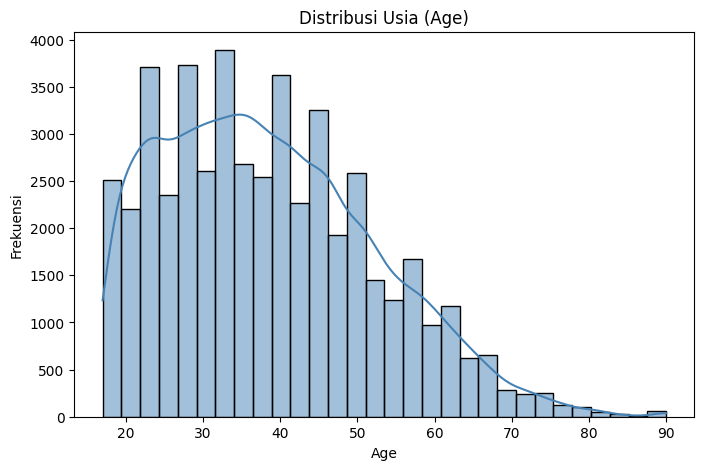

In [ ]:
# Jawab 1.1 - Histrogram

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Usia (Age)')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

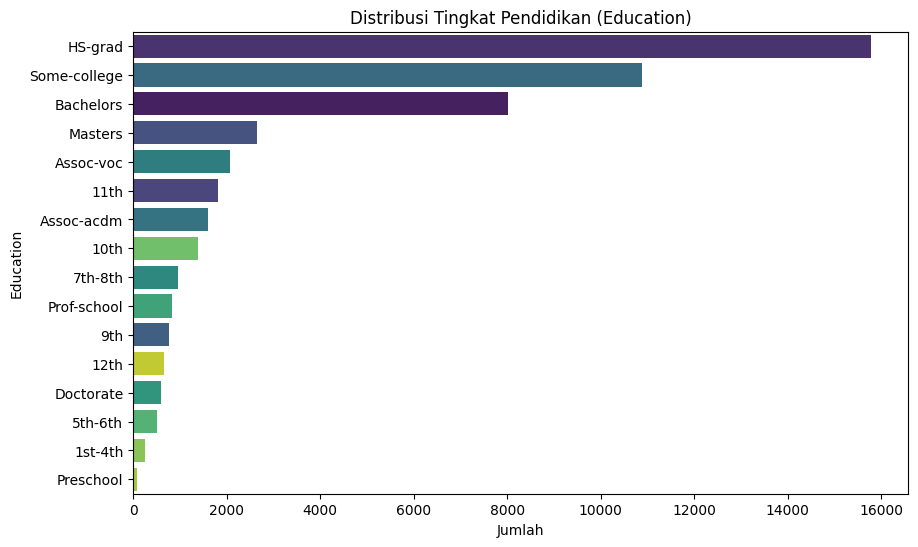

In [ ]:
# Jawab 1.2 - Barchart

plt.figure(figsize=(10,6))
urutan = df['education'].value_counts().index
sns.countplot(data=df, y='education', order=urutan, hue='education', palette='viridis', legend=False)
plt.title('Distribusi Tingkat Pendidikan (Education)')
plt.xlabel('Jumlah')
plt.ylabel('Education')
plt.show()

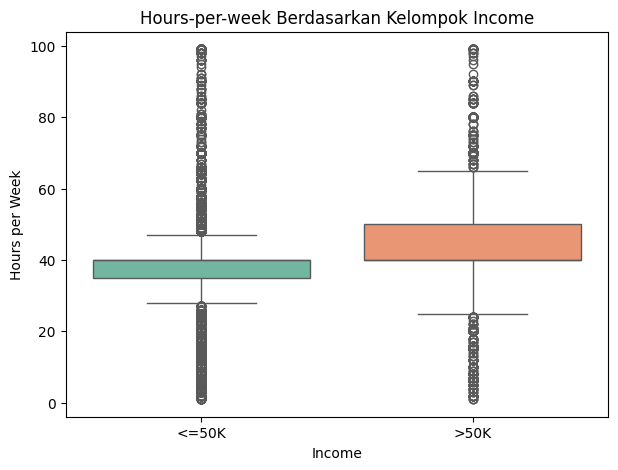

In [ ]:
# Jawab 1.3 - Boxplot

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='income', y='hours-per-week', hue='income', palette='Set2', legend=False)
plt.title('Hours-per-week Berdasarkan Kelompok Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

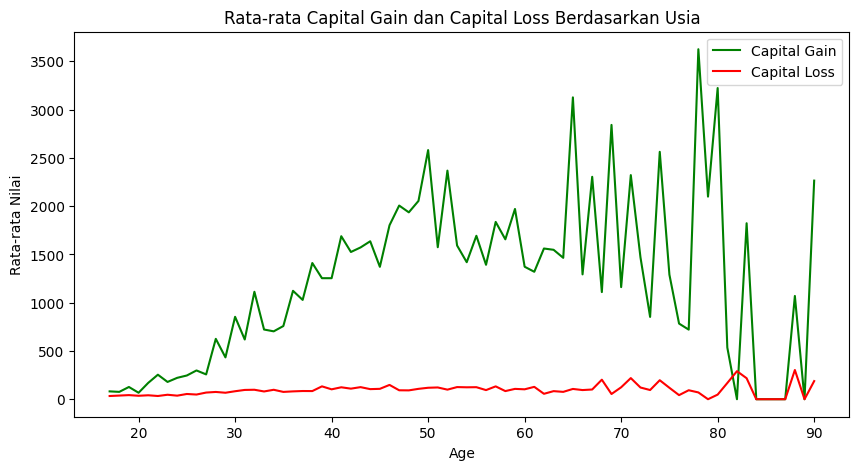

In [ ]:
# Jawab 1.4 - Lineplot

# Karena data mentah bersifat individual (bukan time series), untuk lineplot yang informatif
# kita rata-ratakan capital-gain dan capital-loss per kelompok usia (age)
agg = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(agg['age'], agg['capital-gain'], label='Capital Gain', color='green')
plt.plot(agg['age'], agg['capital-loss'], label='Capital Loss', color='red')
plt.title('Rata-rata Capital Gain dan Capital Loss Berdasarkan Usia')
plt.xlabel('Age')
plt.ylabel('Rata-rata Nilai')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawab dengan komentar python

'''
1. Fenomena yang terjadi pada distribusi data 'age':
   Berdasarkan histogram pada Soal 1.1, distribusi usia berbentuk right-skewed
   (condong/miring ke kanan / positive skew). Mayoritas individu berada pada
   rentang usia produktif (sekitar 20-45 tahun), sementara jumlah individu
   semakin sedikit seiring bertambahnya usia, membentuk ekor distribusi yang
   memanjang ke arah usia lanjut (60-90 tahun).

2. Strategi jika terdapat missing value pada variabel 'age':
   Karena distribusi 'age' tidak simetris (skewed), strategi imputasi yang lebih
   tepat adalah menggunakan MEDIAN, bukan mean. Median lebih robust terhadap
   outlier dan data yang miring dibandingkan mean, sehingga nilai imputasi tidak
   akan menggeser/mendistorsi distribusi data secara signifikan seperti yang bisa
   terjadi apabila menggunakan mean pada data yang tidak simetris.

3. Jumlah outlier hours-per-week pada tiap kategori income (metode IQR):
   Lihat hasil perhitungan pada kode di bawah ini.
'''

# Perhitungan jumlah outlier hours-per-week per kategori income menggunakan metode IQR
for kategori in sorted(df['income'].unique()):
    subset = df[df['income'] == kategori]['hours-per-week']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    outlier = subset[(subset < batas_bawah) | (subset > batas_atas)]
    print(f"Income '{kategori}': jumlah outlier = {len(outlier)} (dari total {len(subset)} data)")


Income '<=50K': jumlah outlier = 11706 (dari total 37155 data)
Income '>50K': jumlah outlier = 781 (dari total 11687 data)


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [ ]:
# Jawab Soal 1

from sklearn.preprocessing import LabelEncoder

# Encoding 'sex'
le_sex = LabelEncoder()
df['sex_encoded'] = le_sex.fit_transform(df['sex'])
print("Mapping sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

# Encoding 'income' (variabel target)
le_income = LabelEncoder()
df['income_encoded'] = le_income.fit_transform(df['income'])
print("Mapping income:", dict(zip(le_income.classes_, le_income.transform(le_income.classes_))))

df[['sex', 'sex_encoded', 'income', 'income_encoded']].head()

Mapping sex: {'Female': np.int64(0), 'Male': np.int64(1)}
Mapping income: {'<=50K': np.int64(0), '>50K': np.int64(1)}


,sex,sex_encoded,income,income_encoded
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

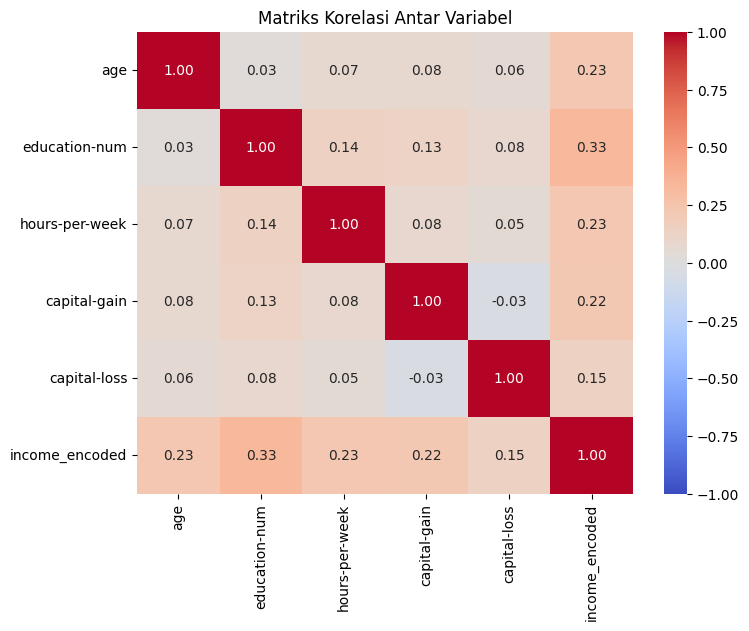

,age,education-num,hours-per-week,capital-gain,capital-loss,income_encoded
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.230369
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.332613
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.227687
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.223013
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.147554
income_encoded,0.230369,0.332613,0.227687,0.223013,0.147554,1.000000


In [ ]:
# Jawab Soal 1

kolom_korelasi = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income_encoded']
korelasi = df[kolom_korelasi].corr()

plt.figure(figsize=(8,6))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriks Korelasi Antar Variabel')
plt.show()

korelasi

In [ ]:
# Hasil analisis jelaskan pada cell ini

'''
Berdasarkan matriks korelasi di atas:

- 'education-num' umumnya menunjukkan korelasi positif yang paling kuat terhadap
  'income' dibandingkan variabel numerik lain, mengindikasikan bahwa semakin tinggi
  tingkat pendidikan (dalam jumlah tahun), semakin besar kecenderungan seseorang
  memiliki penghasilan >50K.

- 'age' dan 'hours-per-week' juga berkorelasi positif terhadap 'income', namun
  dengan kekuatan yang lemah-sedang. Ini menunjukkan usia yang lebih matang dan
  jam kerja yang lebih banyak cenderung berasosiasi dengan penghasilan yang lebih
  tinggi, meskipun hubungannya tidak sekuat 'education-num'.

- 'capital-gain' dan 'capital-loss' cenderung memiliki korelasi positif yang sangat
  lemah terhadap 'income' secara linear. Hal ini terjadi karena sebagian besar
  individu memiliki nilai 0 pada kedua kolom tersebut, sehingga korelasi Pearson
  (yang mengukur hubungan linear) menjadi kurang representatif meskipun secara
  praktik kedua variabel ini tetap berkaitan dengan status income seseorang.

- Secara umum tidak ditemukan korelasi yang sangat kuat (>0.7) antar variabel
  numerik ini, sehingga tidak ada indikasi multikolinearitas yang serius apabila
  variabel-variabel tersebut digunakan bersama dalam model prediksi.
'''

"\nBerdasarkan matriks korelasi di atas:\n\n- 'education-num' umumnya menunjukkan korelasi positif yang paling kuat terhadap\n  'income' dibandingkan variabel numerik lain, mengindikasikan bahwa semakin tinggi\n  tingkat pendidikan (dalam jumlah tahun), semakin besar kecenderungan seseorang\n  memiliki penghasilan >50K.\n\n- 'age' dan 'hours-per-week' juga berkorelasi positif terhadap 'income', namun\n  dengan kekuatan yang lemah-sedang. Ini menunjukkan usia yang lebih matang dan\n  jam kerja yang lebih banyak cenderung berasosiasi dengan penghasilan yang lebih\n  tinggi, meskipun hubungannya tidak sekuat 'education-num'.\n\n- 'capital-gain' dan 'capital-loss' cenderung memiliki korelasi positif yang sangat\n  lemah terhadap 'income' secara linear. Hal ini terjadi karena sebagian besar\n  individu memiliki nilai 0 pada kedua kolom tersebut, sehingga korelasi Pearson\n  (yang mengukur hubungan linear) menjadi kurang representatif meskipun secara\n  praktik kedua variabel ini tetap berka

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [ ]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


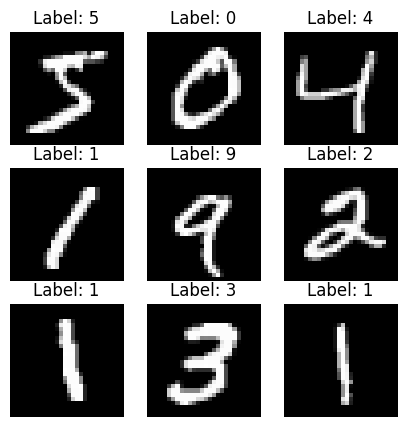

In [ ]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape sebelum upsampling: (10000, 28, 28)
Shape setelah upsampling : (10000, 32, 32)


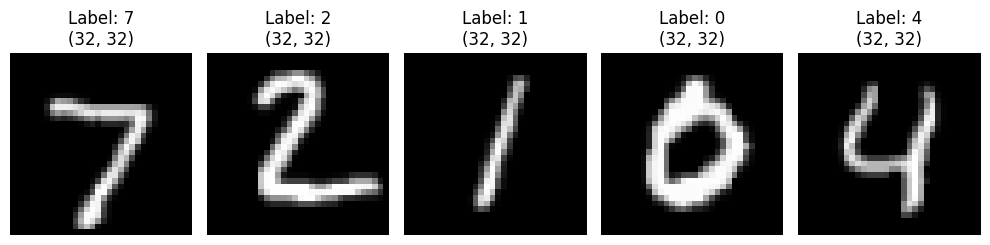

In [ ]:
# Jawab Soal 1

import cv2

# Buat array kosong untuk menampung hasil upsampling, ukuran (10000, 32, 32)
X_test_upsampled = np.zeros((X_test.shape[0], 32, 32), dtype=X_test.dtype)

for i in range(X_test.shape[0]):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_LINEAR)

print("Shape sebelum upsampling:", X_test.shape)
print("Shape setelah upsampling :", X_test_upsampled.shape)

# Tampilkan 5 data hasil upsampling
plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}\n{X_test_upsampled[i].shape}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [ ]:
# Jawab Soal 2

# Normalisasi nilai piksel dari rentang [0, 255] menjadi [0, 1]
X_test_normalized = X_test_upsampled.astype('float32') / 255.0

print("Sebelum normalisasi -> min:", X_test_upsampled.min(), ", max:", X_test_upsampled.max())
print("Setelah normalisasi  -> min:", X_test_normalized.min(), ", max:", X_test_normalized.max())

Sebelum normalisasi -> min: 0 , max: 255
Setelah normalisasi  -> min: 0.0 , max: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [ ]:
# Jawab Soal 3

# Holder array kosong untuk menampung hasil flatten, ukuran (10000, 32*32)
X_test_flatten = np.zeros((X_test_normalized.shape[0], 32 * 32), dtype=X_test_normalized.dtype)

for i in range(X_test_normalized.shape[0]):
    X_test_flatten[i] = X_test_normalized[i].flatten()

print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flatten.shape)

Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)
